# 1. Theory and Practice of Embeddings
In this section, we will explore how we transform text into numerical vectors. We will see the difference between models that understand only words/entities and those that understand logical context.

### 1.0. Static vs. Dynamic Embeddings

Before running the models, it is important to understand their architecture:

*   **Static Embeddings (e.g., Word2Vec, GloVe, Poincare):** Each word has a single fixed vector. 'Cold' (the illness) and 'Cold' (the temperature) would have the same vector, regardless of context. They are fast but limited in medicine where context changes meaning.
*   **Dynamic/Contextual Embeddings (e.g., SapBERT, DeBERTa):** The vector of a word changes depending on the surrounding words. Transformer-type models 'attend' to context, allowing for the distinction between fine clinical nuances.

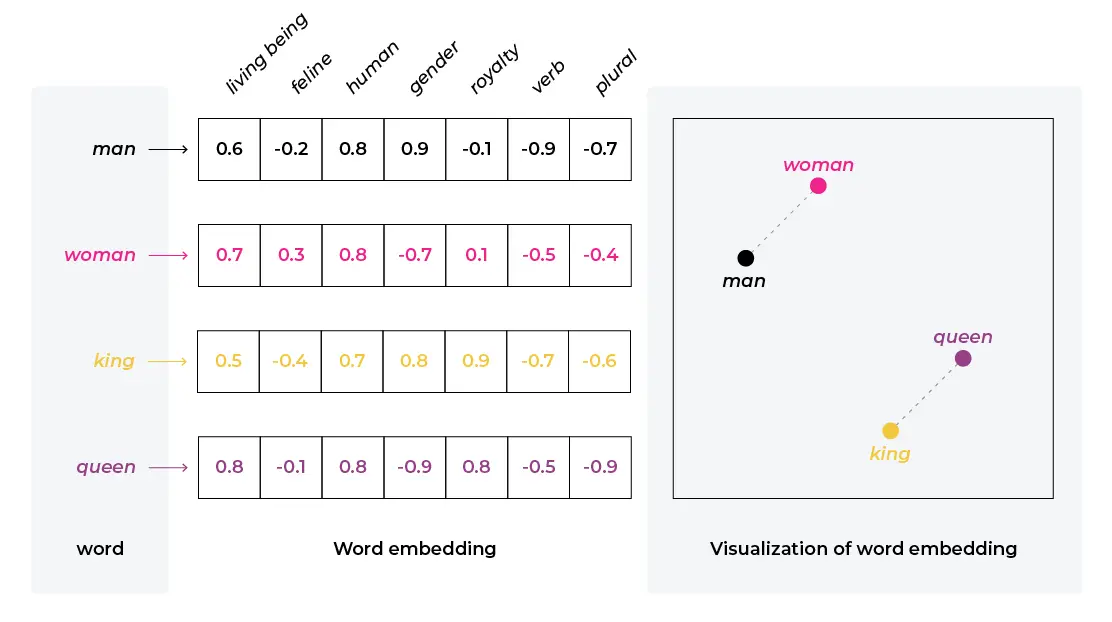

*Image source: "https://arize.com/blog-course/embeddings-meaning-examples-and-how-to-compute/"*


### 1.3. Attention vs. Cross-Attention (Bi-Encoder vs. Cross-Encoder)

What we did above with FAISS is based on a **Bi-Encoder** architecture.
*   **Bi-Encoder (Very Fast):** Transforms the Question into a Vector, then transforms the Document into a Vector independently (separate Self-Attention). Finally, it measures the distance. It is sufficient for finding the Top 10 relevant documents out of a million.

**But how do we achieve surgical accuracy? This is where the Cross-Encoder (Re-Ranking) comes in.**
*   **Cross-Encoder (Very Precise but Slow):** Does not pre-calculate vectors. It receives `[Question + Document]` as a single package. Inside the model, **Cross-Attention** occurs: the model evaluates every word in the question in direct relation to every word in the document simultaneously, outputting a supreme relevance score directly.

**Clear Application (Production RAG Pipeline):**
1. Use a **Bi-Encoder** (FAISS) to filter roughly and quickly the first 50 results from a million.
2. Pass those 50 results through a **Cross-Encoder** to obtain a second, high-finesse sorting (Re-Ranking) and extract the Top 3 best results to send to the LLM.

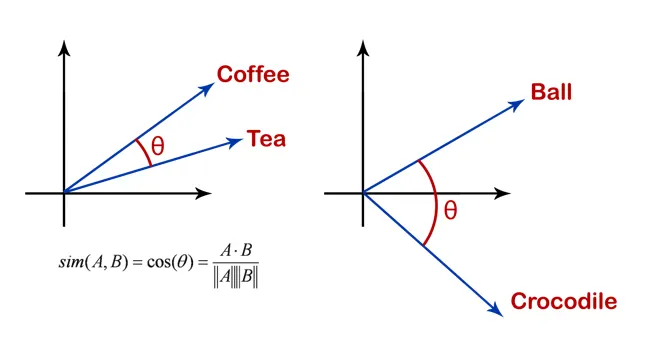

*Source: https://www.freecodecamp.org/news/how-does-cosine-similarity-work/*

In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch
import torch.nn.functional as F

# Models
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

user_question = "How many hours does a cat usually sleep?"

retrieved_documents = [
    "The dog is man's best friend and sleeps 10 hours.",
    "A domestic feline spends on average between 12 and 16 hours a day resting.",
    "The National Bank of Romania sleeps on a gold reserve.",
    "Cats are active hunters and they don't sleep at all during the night hours.",
    "The construction worker spent 8 hours at the site before going to sleep."
]

print(f"Question: {user_question}\n")

# --- BI-ENCODER APPROACH ---
print("--- BI-ENCODER (Cosine Similarity) ---")
query_emb = bi_encoder.encode(user_question, convert_to_tensor=True)
doc_embs = bi_encoder.encode(retrieved_documents, convert_to_tensor=True)
bi_scores = util.cos_sim(query_emb, doc_embs)[0]

bi_results = sorted(zip(bi_scores, retrieved_documents), key=lambda x: x[0], reverse=True)
for score, doc in bi_results:
    print(f"Sim: {score*100:.2f}% | {doc}")

# --- CROSS-ENCODER APPROACH WITH SOFTMAX ---
print("\n--- CROSS-ENCODER (Softmax Probabilities in %) ---")
perechi = [[user_question, doc] for doc in retrieved_documents]
cross_scores_raw = cross_encoder.predict(perechi)

# Apply Softmax to transform logits into probabilities (sum = 1)
cross_scores_softmax = F.softmax(torch.tensor(cross_scores_raw), dim=0)

cross_results = sorted(zip(cross_scores_softmax, retrieved_documents), key=lambda x: x[0], reverse=True)
for score, doc in cross_results:
    print(f"Prob: {score*100:.2f}% | {doc}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Question: How many hours does a cat usually sleep?

--- BI-ENCODER (Cosine Similarity) ---
Sim: 72.41% | Cats are active hunters and they don't sleep at all during the night hours.
Sim: 71.23% | A domestic feline spends on average between 12 and 16 hours a day resting.
Sim: 51.63% | The dog is man's best friend and sleeps 10 hours.
Sim: 39.96% | The construction worker spent 8 hours at the site before going to sleep.
Sim: 23.66% | The National Bank of Romania sleeps on a gold reserve.

--- CROSS-ENCODER (Softmax Probabilities in %) ---
Prob: 99.45% | A domestic feline spends on average between 12 and 16 hours a day resting.
Prob: 0.54% | Cats are active hunters and they don't sleep at all during the night hours.
Prob: 0.01% | The dog is man's best friend and sleeps 10 hours.
Prob: 0.00% | The construction worker spent 8 hours at the site before going to sleep.
Prob: 0.00% | The National Bank of Romania sleeps on a gold reserve.


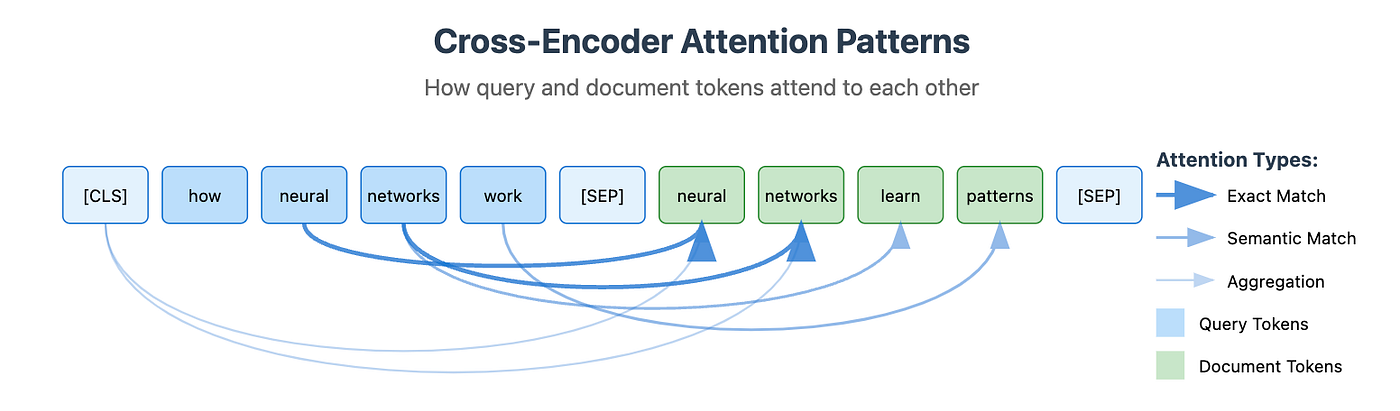

*Source: https://medium.com/@kakumar1611/the-illustrated-guide-to-cross-encoders-from-deep-to-shallow-2a23a8630016*

### Understanding Cross-Encoders: Deep Interaction for Precision

In a **Cross-Encoder**, the question and the document are not treated as two separate entities. Instead, they are concatenated into a single long sequence, separated by a special keyword, like this:
`[START] Question [SEPARATOR] Document [FINAL]`

When this package enters the model, the **Attention mechanism** (Self-Attention in the Transformer architecture) creates a massive matrix where:
1.  Every word in the **Question** looks at **every word in the Document**.
2.  Every word in the **Document** looks back at **every word in the Question**.
3.  Every word in the **Question** looks at other words in the *Question* (for local context).
4.  Every word in the **Document** looks at other words in the *Document* (for local context).

This massive "spider web" of mathematical connections allows the model to understand **nuances, negations, and causal relationships** that a Bi-Encoder (which isolates the texts) completely misses.

## In the Real World: When the Bi-Encoder Fails Miserably

In an Insurance customer support system, a user asks:
**"Does my insurance cover damages if I HIT AN ANIMAL on the highway?"**

We have two documents in the database:
*   **Document A (Correct):** "The auto policy covers repairs in the event of a collision with wildlife on public roads." *(Identical meaning, but totally different words: auto, repairs, collision, wildlife)*
*   **Document B (Wrong/Trap):** "If you are hit on the highway, the insurance does not cover damages if you were transporting a pet animal." *(Wrong meaning, but contains the exact words from the question: hit, highway, insurance, cover, damages, animal)*

While a Bi-Encoder might rank Document B higher due to word overlap, a **Cross-Encoder** will correctly identify that Document A is the relevant answer by processing the semantic relationship between the query and the document text simultaneously.

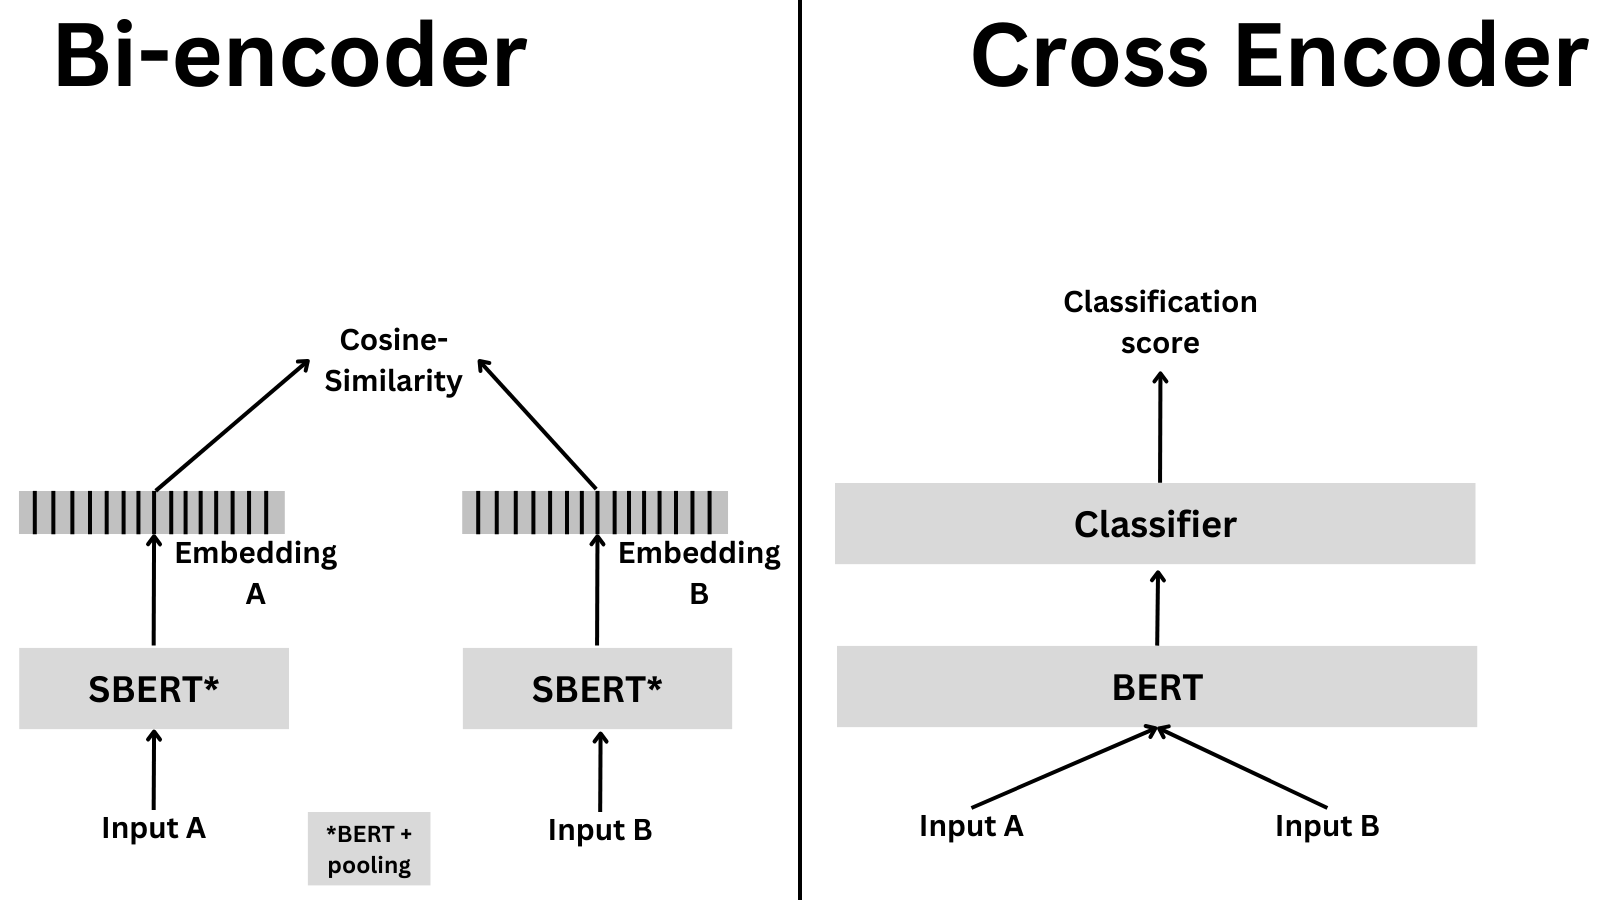

*Source: https://osanseviero.github.io/hackerllama/blog/posts/sentence_embeddings2/*

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer, CrossEncoder, util

# 1. Models
bi_model = SentenceTransformer('all-MiniLM-L6-v2')
cross_ranking = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
cross_nli = CrossEncoder('cross-encoder/nli-deberta-v3-base')

query = "I want a flight from Paris to London."
doc_a_inverse = "flights from London to Paris."
doc_b_correct = "airlines departing from the French capital and arriving in the UK."
documents = [doc_a_inverse, doc_b_correct]

print(f"Query: {query}\n")

# --- TEST 1: BI-ENCODER (MiniLM) ---
query_embedding = bi_model.encode(query)
doc_embeddings = bi_model.encode(documents)
sims_bi = util.cos_sim(query_embedding, doc_embeddings)[0]

print("--- BI-ENCODER (Cosine Similarity) ---")
print(f"Doc A (Inverse): {sims_bi[0]*100:.2f}% <-- Prefers identical words")
print(f"Doc B (Correct): {sims_bi[1]*100:.2f}%\n")

# --- TEST 2: CROSS-ENCODER RANKING (MiniLM) ---
pairs = [[query, doc] for doc in documents]
scores_rank = cross_ranking.predict(pairs)
# Softmax on the document axis to see relevance distribution
probs_rank = F.softmax(torch.tensor(scores_rank), dim=0).numpy()

print("--- CROSS-ENCODER RANKING (Relevance Probability) ---")
print(f"Doc A (Inverse): {probs_rank[0]*100:.2f}%")
print(f"Doc B (Correct): {probs_rank[1]*100:.2f}%\n")

# --- TEST 3: CROSS-ENCODER NLI (DeBERTa v3) ---
scores_nli_raw = cross_nli.predict(pairs)
# Softmax on the class axis (0: Contradiction, 1: Entailment, 2: Neutral)
probs_nli = F.softmax(torch.tensor(scores_nli_raw), dim=1).numpy()

labels = ["Contradiction", "Entailment", "Neutral"]

print("--- DEBERTA NLI (Probability Distribution) ---")
for i, doc_label in enumerate(["Doc A (Inverse)", "Doc B (Correct)"]):
    print(f"{doc_label}:")
    for j, label in enumerate(labels):
        print(f"  - {label}: {probs_nli[i][j]*100:.2f}%")

print("\nConclusion: Only DeBERTa logically confirms the correct destination with a high Entailment probability, while the inverse flight is seen as a Contradiction.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Query: I want a flight from Paris to London.

--- BI-ENCODER (Cosine Similarity) ---
Doc A (Inverse): 88.49% <-- Prefers identical words
Doc B (Correct): 64.41%

--- CROSS-ENCODER RANKING (Relevance Probability) ---
Doc A (Inverse): 99.98%
Doc B (Correct): 0.02%

--- DEBERTA NLI (Probability Distribution) ---
Doc A (Inverse):
  - Contradiction: 99.56%
  - Entailment: 0.14%
  - Neutral: 0.30%
Doc B (Correct):
  - Contradiction: 0.01%
  - Entailment: 98.98%
  - Neutral: 1.01%

Conclusion: Only DeBERTa logically confirms the correct destination with a high Entailment probability, while the inverse flight is seen as a Contradiction.


In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch
import torch.nn.functional as F

# 1. Load BOTH models
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

# Scenario
query = "Does my insurance cover damages if I hit an animal on the highway?"
doc_a_corect = "The auto policy covers repairs in the event of a collision with wildlife on public roads."
doc_b_capcana = "If you are hit on the highway, the insurance does not cover damages if you were transporting a pet animal."

documente = [doc_a_corect, doc_b_capcana]

# --- TEST 1: BI-ENCODER ---
query_emb = bi_encoder.encode(query)
doc_embs = bi_encoder.encode(documente)
scoruri_bi = util.cos_sim(query_emb, doc_embs)[0]

print("--- BI-ENCODER RESULTS (Cosine Sim) ---")
print(f"Score Doc A (Correct):  {scoruri_bi[0]:.4f}")
print(f"Score Doc B (Trap): {scoruri_bi[1]:.4f}  <-- FAISS would choose incorrectly!")

# --- TEST 2: CROSS-ENCODER WITH SOFTMAX ---
perechi = [[query, doc] for doc in documente]
scoruri_raw = cross_encoder.predict(perechi)

# Apply Softmax
scoruri_softmax = F.softmax(torch.tensor(scoruri_raw), dim=0)

print("\n--- CROSS-ENCODER RESULTS (Softmax Probabilities) ---")
print(f"Prob Doc A (Correct):  {scoruri_softmax[0]:.4f} <-- Clear winner!")
print(f"Prob Doc B (Trap): {scoruri_softmax[1]:.4f}")
print("\nObservation: The Cross-Encoder understood the logic, not just the words.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

--- BI-ENCODER RESULTS (Cosine Sim) ---
Score Doc A (Correct):  0.6350
Score Doc B (Trap): 0.9247  <-- FAISS would choose incorrectly!

--- CROSS-ENCODER RESULTS (Softmax Probabilities) ---
Prob Doc A (Correct):  0.0000 <-- Clear winner!
Prob Doc B (Trap): 1.0000

Observation: The Cross-Encoder understood the logic, not just the words.


# 📘 DeBERTa: The Evolution of Semantic Intelligence

**DeBERTa** is a Transformer-based model introduced by Microsoft in 2020, which surpassed human performance on the SuperGLUE benchmark. It is considered the direct and much more intelligent successor to the BERT and RoBERTa models.

Why did DeBERTa succeed where other models failed? The secret lies in two major innovations: **Disentangled Attention** and the **Enhanced Mask Decoder**.

## 1. Disentangled Attention

In classic models like BERT, each word in a sentence is represented by a single vector that sums up two things: **content** (what the word means) and **position** (where it is in the sentence).

DeBERTa does something different: it uses **two separate vectors** for each word.
* **Content Vector:** Represents the meaning of the word.
* **Position Vector:** Represents the relative distance from other words.

When the model calculates the relationship between two words (for example, "Paris" and "London"), it analyzes separately:
1.  **Content to Content:** How close are their meanings?
2.  **Content to Position:** Does it matter that "Paris" is the subject (at the beginning) and "London" is the destination (at the end)?
3.  **Position to Content:** How does the word's location influence the meaning of the other?

**Why it matters:** In our flight example, BERT only saw "Paris" and "London" as content. DeBERTa understood that their positional relationship (who is the source and who is the destination) is crucial and separate from the words themselves.

## 2. Enhanced Mask Decoder (EMD)

In the training phase, models "guess" missing words. DeBERTa uses information about the absolute position of words at the exact moment it tries to reconstruct the text. This gives it a much greater capacity to understand **syntax** (the correct order of words in language).

## 3. Quick Comparison

| Feature | BERT | RoBERTa | DeBERTa |
| :--- | :--- | :--- | :--- |
| **Positioning** | Absolute (embedded in the word) | Absolute | Relative and Disentangled |
| **Logic** | Good for general context | Excellent for general context | Superior for logical reasoning |
| **Performance** | Baseline | Optimized through data | Optimized through architecture |

---

## 🚀 Why is it the perfect choice for NLI (Natural Language Inference)?

Natural Language Inference involves deciding whether Sentence A logically implies Sentence B. This requires more than "keyword searching"; it requires understanding grammatical roles:
* *Who* performs the action?
* *Where* is it headed?
* *What* is the order of events?

DeBERTa excels here because it is not fooled by the fact that two sentences have the same words. It analyzes the "invisible structure" of the phrase.

### Our practical example:
* **Query:** "I want a flight from **Paris** to **London**."
* **Doc A:** "...from **London** to **Paris**."
* **DeBERTa Analysis:** Although the content (Paris, London) matches 100%, the **relative position** vectors indicate a total contradiction.

---

## How is it used in Python?

As we have seen, the simplest method is through the `sentence-transformers` library:

```python
from sentence_transformers import CrossEncoder

model = CrossEncoder('cross-encoder/nli-deberta-v3-base')
scores = model.predict([("Sentence 1", "Sentence 2")])
# Scores are: [Contradiction, Entailment, Neutral]
```

**Conclusion:** If you have a RAG (Retrieval-Augmented Generation) system and logical accuracy is critical (for example in medical, legal, or financial applications), a DeBERTa-based model as a Reranking step is essential.

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer, CrossEncoder, util

# 1. Load the models
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')
# Change the model to DeBERTa (NLI) - specifically trained for logic and inference
cross_encoder_nli = CrossEncoder('cross-encoder/nli-deberta-v3-base')

# Scenario (in English for maximum model accuracy)
query = "Does my insurance cover damages if I hit an animal on the highway?"

doc_a_corect = "The auto policy covers repairs in the event of a collision with wildlife on public roads."
doc_b_capcana = "If you are hit on the highway, the insurance does not cover damages if you were transporting a pet animal."

documente = [doc_a_corect, doc_b_capcana]

# ==========================================
# TEST 1: BI-ENCODER (How FAISS / Vector DB thinks)
# ==========================================
query_emb = bi_encoder.encode(query)
doc_embs = bi_encoder.encode(documente)

scoruri_bi = util.cos_sim(query_emb, doc_embs)[0]

print("--- BI-ENCODER RESULTS (MiniLM) ---")
print(f"Score Doc A (Correct):  {scoruri_bi[0]:.4f}")
print(f"Score Doc B (Trap): {scoruri_bi[1]:.4f}")

# ==========================================
# TEST 2: CROSS-ENCODER (DeBERTa NLI)
# ==========================================
perechi = [[query, doc] for doc in documente]

# NLI models return 3 values for each pair: [Contradiction, Entailment, Neutral]
scoruri_nli_brute = cross_encoder_nli.predict(perechi)

print("--- CROSS-ENCODER NLI RESULTS (DeBERTa-v3) ---")
for i, doc in enumerate(["Doc A (Correct)", "Doc B (Trap)"]):
    # Apply F.softmax to the 3 scores of the current document
    probabilitati = F.softmax(torch.tensor(scoruri_nli_brute[i]), dim=0).numpy()

    # Index 0 = Contradiction, Index 1 = Entailment, Index 2 = Neutral
    scor_logica = probabilitati[1] * 100

    print(f"Logical Probability {doc}: {scor_logica:.2f}%")

print("\nConclusion: DeBERTa doesn't just look at words; it asks: 'If the statement in the Document is true, does it logically answer (Entailment) the Question?'. It analyzes cause and effect!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

--- BI-ENCODER RESULTS (MiniLM) ---
Score Doc A (Correct):  0.6350
Score Doc B (Trap): 0.9247
--- CROSS-ENCODER NLI RESULTS (DeBERTa-v3) ---
Logical Probability Doc A (Correct): 98.80%
Logical Probability Doc B (Trap): 0.52%

Conclusion: DeBERTa doesn't just look at words; it asks: 'If the statement in the Document is true, does it logically answer (Entailment) the Question?'. It analyzes cause and effect!


# From Papers to Precision: Building Biomedical Intelligence at Scale

This notebook demonstrates an end-to-end pipeline for extracting biomedical insights from scientific literature and structuring them into a Knowledge Graph.

### Pipeline Overview:
1. **Data Ingestion**: Programmatic access to PubMed using Biopython.
2. **NLP Extraction**: Zero-shot Named Entity Recognition (NER) and Relation Extraction using GLiNER.
3. **Knowledge Graph**: Storing structured triplets in Neo4j AuraDB.
4. **Visualization**: Interactive graph rendering with Pyvis.

## Step 1: Environment Setup

We need specific libraries for our pipeline:
* `gliner`: For zero-shot entity and relation extraction.
* `biopython`: To interface with NCBI's Entrez (PubMed).
* `neo4j`: Official driver for the graph database.
* `pyvis` & `networkx`: For interactive browser-based visualizations.

In [ ]:
# 1. Environment & Dependencies (Re-installing to ensure pyvis is present)
!pip install -q gliner biopython pyvis networkx pandas matplotlib seaborn

import os, time, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from Bio import Entrez
from gliner import GLiNER
from pyvis.network import Network
from IPython.display import HTML

print("Core Setup Complete.")

Core Setup Complete.


In [ ]:
import numpy as np
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer

# Initialize embedding model for Hybrid RAG
embed_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')#'all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Helper for Entity Linking
def resolve_entity(name, registry, model, threshold=0.92):
    """Finds an existing canonical name or adds the new one to the registry."""
    name_clean = name.strip()
    if not registry:
        emb = model.encode([name_clean])[0]
        registry[name_clean] = emb
        return name_clean, emb

    # Check for semantic matches
    canonical_names = list(registry.keys())
    canonical_vecs = np.array(list(registry.values()))
    new_vec = model.encode([name_clean])[0]

    similarities = cosine_similarity([new_vec], canonical_vecs)[0]
    best_idx = np.argmax(similarities)

    if similarities[best_idx] >= threshold:
        return canonical_names[best_idx], canonical_vecs[best_idx]
    else:
        registry[name_clean] = new_vec
        return name_clean, new_vec

## Step 2: Data Ingestion via PubMed API

NCBI requires an email address for their API usage. We will use the `Entrez` module to search for recent articles regarding Lung Cancer resistance and retrieve their abstracts.

In [ ]:
# 2. Clean Data Ingestion
Entrez.email = "researcher@example.com"

def fetch_abstracts(query, count=5):
    print(f"Searching: {query}")
    handle = Entrez.esearch(db="pubmed", term=query, retmax=count)
    id_list = Entrez.read(handle)["IdList"]

    docs = []
    for pmid in id_list:
        h = Entrez.efetch(db="pubmed", id=pmid, rettype="abstract", retmode="xml")
        art = Entrez.read(h)['PubmedArticle'][0]['MedlineCitation']['Article']
        text = " ".join(art.get('Abstract', {}).get('AbstractText', [""]))
        docs.append({"pmid": pmid, "title": art['ArticleTitle'], "text": text})
        print(f" - Fetched: {pmid}")
        time.sleep(0.2)
    return docs

articles = fetch_abstracts("(Lung Cancer) AND (EGFR) AND (Resistance)")

Searching: (Lung Cancer) AND (EGFR) AND (Resistance)
 - Fetched: 42338283
 - Fetched: 42336655
 - Fetched: 42336028
 - Fetched: 42333846
 - Fetched: 42329235


### Scaling Data Ingestion
We are increasing the `max_results` to 100 to build a more robust knowledge graph for analysis.

## Step 3: Biomedical Entity & Relation Extraction

Traditional NLP requires training on specific datasets. **GLiNER** allows us to perform zero-shot extraction. We will identify `Diseases`, `Genes`, and `Drugs`, then attempt to infer relationships.

In [ ]:
# 3. Intelligent Relationship Extraction (Fixed Tuple Unpacking)
model = GLiNER.from_pretrained("knowledgator/gliner-relex-large-v1.0")
labels = ["Disease", "Gene", "Drug", "Mutation"]
relations = ["treats", "inhibits", "causes", "targets"]

all_triplets = []
print("Discovering relationships...")
for a in articles:
    # GLiNER predict_relations returns a tuple: (entities, relationships)
    res = model.predict_relations(a['text'], labels, relations, threshold=0.1)

    if isinstance(res, tuple) and len(res) > 1:
        extracted_rels = res[1]
        all_triplets.extend(extracted_rels)
    elif isinstance(res, list):
        all_triplets.extend(res)

print(f"Found {len(all_triplets)} relationship triplets.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Discovering relationships...
Found 278 relationship triplets.


In [ ]:
def extract_biomedical_triplets(text, title="Unknown"):
    """
    Helper function to wrap GLiNER prediction and classify the status of the relationship.
    """
    res = model.predict_relations(text, labels, relations, threshold=0.1)

    # GLiNER returns (entities, relations)
    raw_triplets = res[1] if isinstance(res, tuple) and len(res) > 1 else []

    # Keywords to differentiate evidence types
    experimental_keywords = ['preclinical', 'in vitro', 'in vivo', 'mouse', 'murine', 'cell line', 'laboratory', 'pre-clinical']

    formatted_triplets = []
    for t in raw_triplets:
        context_snippet = text.lower()
        # Simple classification logic
        status = "Mentioned"
        if any(kw in context_snippet for kw in experimental_keywords):
            status = "Experimental/Preclinical"
        elif "approved" in context_snippet or "standard of care" in context_snippet:
            status = "Clinical/Standard"

        formatted_triplets.append({
            'head_entity': {
                'text': t['head']['text'],
                'label': t['head'].get('type', 'Entity')
            },
            'tail_entity': {
                'text': t['tail']['text'],
                'label': t['tail'].get('type', 'Entity')
            },
            'relation': t['relation'],
            'score': round(t.get('score', 0), 4),
            'status': status,
            'context': text[:250] + "..."
        })
    return formatted_triplets

In [ ]:
import pandas as pd

# Fix: Defining the missing query and fetching articles first
query = "(Lung Cancer) AND (EGFR) AND (Resistance)"
scaled_articles = fetch_abstracts(query, count=10)

print("--- Diagnostic: Relationship Extraction ---")
found_count = 0
all_extracted_triplets = []

# Loop through all scaled_articles to ensure comprehensive testing
for art in scaled_articles:
    # Using the initialized 'model' and predict_relations logic
    res = model.predict_relations(art['text'], labels, relations, threshold=0.1)

    # Handling the GLiNER output format (entities, relations)
    triplets = res[1] if isinstance(res, tuple) and len(res) > 1 else res

    if triplets:
        found_count += 1
        all_extracted_triplets.extend(triplets)
        print(f"PMID {art['pmid']}: [Success! {len(triplets)} triplets found]")

if found_count > 0:
    print(f"\nSuccessfully extracted triplets from {found_count} out of {len(scaled_articles)} articles.")
    print(f"Total unique triplets found: {len(all_extracted_triplets)}")

    # Fix: Corrected 'label' to 'type' to match GLiNER output keys
    df = pd.DataFrame([{
        'Head': t['head']['text'],
        'H_Label': t['head'].get('type', 'Unknown'),
        'Relation': t['relation'],
        'Tail': t['tail']['text'],
        'T_Label': t['tail'].get('type', 'Unknown'),
        'Score': round(t.get('score', 0), 4)
    } for t in all_extracted_triplets])
    display(df.head(10))
else:
    print("\nNo triplets were extracted. This suggests the zero-shot model may require more specific labels or a lower confidence threshold.")

Searching: (Lung Cancer) AND (EGFR) AND (Resistance)
 - Fetched: 42338283
 - Fetched: 42336655
 - Fetched: 42336028
 - Fetched: 42333846
 - Fetched: 42329235
 - Fetched: 42328676
 - Fetched: 42326343
 - Fetched: 42325398
 - Fetched: 42324853
 - Fetched: 42321531
--- Diagnostic: Relationship Extraction ---
PMID 42338283: [Success! 70 triplets found]
PMID 42336655: [Success! 78 triplets found]
PMID 42336028: [Success! 56 triplets found]
PMID 42333846: [Success! 23 triplets found]
PMID 42329235: [Success! 51 triplets found]
PMID 42328676: [Success! 15 triplets found]
PMID 42326343: [Success! 30 triplets found]
PMID 42325398: [Success! 87 triplets found]
PMID 42324853: [Success! 19 triplets found]
PMID 42321531: [Success! 37 triplets found]

Successfully extracted triplets from 10 out of 10 articles.
Total unique triplets found: 466


,Head,H_Label,Relation,Tail,T_Label,Score
0,TruSight Oncology 500 ctDNA,Drug,inhibits,therapeutic targets,Gene,0.2940
1,TruSight Oncology 500 ctDNA,Drug,targets,therapeutic targets,Gene,0.8203
2,TruSight Oncology 500 ctDNA,Drug,inhibits,resistance mechanisms,Mutation,0.3270
3,TruSight Oncology 500 ctDNA,Drug,treats,non-small cell lung cancer,Disease,0.7948
4,TruSight Oncology 500 ctDNA,Drug,treats,NSCLC,Disease,0.7053
5,TruSight Oncology 500 ctDNA,Drug,treats,metastatic NSCLC,Disease,0.6681
6,TruSight Oncology 500 ctDNA,Drug,inhibits,molecular drivers,Mutation,0.1076
7,TruSight Oncology 500 ctDNA,Drug,inhibits,mutations,Mutation,0.1338
8,TruSight Oncology 500 ctDNA,Drug,inhibits,ALK,Gene,0.2113
9,TruSight Oncology 500 ctDNA,Drug,inhibits,RET,Gene,0.1559


## Step 4: Knowledge Graph Construction in Neo4j

We will now structure our extracted entities into a graph. We'll use a `MERGE` query in Cypher to ensure we don't create duplicate nodes.

**Note:** You can get a free Neo4j instance at [Neo4j Aura](https://neo4j.com/cloud/aura/).

In [ ]:
!pip install -q neo4j
from neo4j import GraphDatabase

class BioGraphManager:
    def __init__(self, uri, user, password):
        self.driver = GraphDatabase.driver(uri, auth=(user, password))

    def ingest_triplets(self, article, triplets):
        with self.driver.session() as session:
            # 1. Ensure Article exists
            session.run("MERGE (a:Article {pmid: $pmid}) SET a.title = $title",
                        pmid=article['pmid'], title=article['title'])

            # 2. Iterate through extracted relationships
            for triplet in triplets:
                # Fix: Using 'type' key instead of 'label' to match GLiNER output
                head = triplet['head']
                tail = triplet['tail']
                rel_type = triplet['relation'].upper().replace(" ", "_")

                session.run(f"""
                    MERGE (h:{head.get('type', 'Entity')} {{name: $head_name}})
                    MERGE (t:{tail.get('type', 'Entity')} {{name: $tail_name}})
                    MERGE (h)-[r:{rel_type}]->(t)
                    ON CREATE SET
                        r.status = 'Extracted via GLiNER-Rel',
                        r.pmid = $pmid,
                        r.confidence = $score
                """,
                head_name=head['text'],
                tail_name=tail['text'],
                pmid=article['pmid'],
                score=triplet.get('score', 0))

# Usage example:
# manager = BioGraphManager(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)
# for art in scaled_articles[:10]:
#     triplets = extract_biomedical_triplets(art['abstract'])
#     manager.ingest_triplets(art, triplets)

In [ ]:
def get_embedding(text):
    return embed_model.encode(text).tolist()

class EnhancedBioGraphManager(BioGraphManager):
    def ingest_triplets_with_metadata(self, article, triplets):
        with self.driver.session() as session:
            # Link extraction to source article
            session.run("MERGE (a:Article {pmid: $pmid}) SET a.title = $title",
                        pmid=article['pmid'], title=article['title'])

            for triplet in triplets:
                head = triplet['head_entity']
                tail = triplet['tail_entity']
                rel_type = triplet['relation'].upper().replace(" ", "_")

                # Use context from the extractor
                context = triplet.get('context', "")
                is_exp = triplet.get('is_experimental', False)

                session.run(f"""
                    MERGE (h:{head['label']} {{name: $head_name}})
                    ON CREATE SET h.embedding = $h_embed
                    MERGE (t:{tail['label']} {{name: $tail_name}})
                    ON CREATE SET t.embedding = $t_embed
                    MERGE (h)-[r:{rel_type}]->(t)
                    SET
                        r.status = $status,
                        r.pmid = $pmid,
                        r.confidence = $score,
                        r.source_context = $context
                """,
                head_name=head['text'], h_embed=get_embedding(head['text']),
                tail_name=tail['text'], t_embed=get_embedding(tail['text']),
                pmid=article['pmid'],
                score=triplet['score'],
                context=context,
                status="Experimental" if is_exp else "Mentioned")

In [ ]:
!pip install -q kuzu
import kuzu
import shutil
import os

# Clean up any previous demo database safely
db_path = './demo_db'
if os.path.exists(db_path):
    if os.path.isdir(db_path):
        shutil.rmtree(db_path)
    else:
        os.remove(db_path)

class LocalCypherManager:
    def __init__(self, db_path='./demo_db'):
        self.db = kuzu.Database(db_path)
        self.conn = kuzu.Connection(self.db)
        self._setup_schema()
        print(f"Local Graph Database (Kùzu) initialized at {db_path}")

    def _setup_schema(self):
        # Create node tables
        try:
            self.conn.execute("CREATE NODE TABLE Article(pmid STRING, title STRING, PRIMARY KEY (pmid))")
            self.conn.execute("CREATE NODE TABLE Entity(name STRING, label STRING, embedding FLOAT[768], PRIMARY KEY (name))")
            # Create a generic relationship table
            self.conn.execute("CREATE REL TABLE MENTIONED_IN(FROM Entity TO Article)")
            self.conn.execute("CREATE REL TABLE INTERACTS(FROM Entity TO Entity, type STRING, confidence DOUBLE, context STRING)")
        except Exception:
            pass # Tables already exist

    def ingest_triplets_with_metadata(self, article, triplets):
        # 1. Ingest Article
        self.conn.execute("MERGE (a:Article {pmid: $pmid}) SET a.title = $title",
                          {"pmid": str(article['pmid']), "title": article['title']})

        for triplet in triplets:
            h = triplet['head_entity']
            t = triplet['tail_entity']

            # 2. Ingest Nodes
            self.conn.execute("MERGE (h:Entity {name: $n1}) SET h.label = $l1, h.embedding = $e1",
                              {"n1": h['text'], "l1": h['label'], "e1": get_embedding(h['text'])})
            self.conn.execute("MERGE (t:Entity {name: $n2}) SET t.label = $l2, t.embedding = $e2",
                              {"n2": t['text'], "l2": t['label'], "e2": get_embedding(t['text'])})

            # 3. Ingest Relationships
            self.conn.execute("MATCH (h:Entity), (t:Entity) WHERE h.name = $n1 AND t.name = $n2 "
                              "CREATE (h)-[:INTERACTS {type: $rel, confidence: $score, context: $ctx}]->(t)",
                              {"n1": h['text'], "n2": t['text'], "rel": triplet['relation'],
                               "score": float(triplet['score']), "ctx": triplet.get('context', "")})

            # Link to article
            self.conn.execute("MATCH (e:Entity), (a:Article) WHERE e.name = $n1 AND a.pmid = $pmid "
                              "MERGE (e)-[:MENTIONED_IN]->(a)",
                              {"n1": h['text'], "pmid": str(article['pmid'])})

# Instantiate the local manager
enhanced_manager = LocalCypherManager()

Local Graph Database (Kùzu) initialized at ./demo_db


In [ ]:
print("Processing articles into local Graph...")
for art in scaled_articles:
    triplets = extract_biomedical_triplets(art['text'], title=art['title'])
    if triplets:
        enhanced_manager.ingest_triplets_with_metadata(art, triplets)
        print(f"Ingested {len(triplets)} relations for PMID {art['pmid']}")

print("\nLocal Ingestion Complete. You can now run Cypher queries against 'enhanced_manager.conn'.")

Processing articles into local Graph...
Ingested 70 relations for PMID 42338283
Ingested 78 relations for PMID 42336655
Ingested 56 relations for PMID 42336028
Ingested 23 relations for PMID 42333846
Ingested 51 relations for PMID 42329235
Ingested 15 relations for PMID 42328676
Ingested 30 relations for PMID 42326343
Ingested 87 relations for PMID 42325398
Ingested 19 relations for PMID 42324853
Ingested 37 relations for PMID 42321531

Local Ingestion Complete. You can now run Cypher queries against 'enhanced_manager.conn'.


### Step 5: Neo4j Storage and GraphRAG Retrieval

This section handles the persistent storage of extracted triplets and their semantic embeddings. We use a hybrid approach where nodes contain vector representations of the entities, allowing for both structural (Cypher) and semantic (Vector) queries.

In [ ]:
# Example of a Hybrid GraphRAG Retrieval Query
def hybrid_query(manager, entity_name, top_k=5):
    """
    Combined Semantic and Structural Search.
    """
    with manager.driver.session() as session:
        query = """
        MATCH (n {name: $name})-[r]->(neighbor)
        RETURN n.name as Source, type(r) as Rel, neighbor.name as Target,
               r.source_context as Evidence, r.status as Type
        LIMIT $k
        """
        return session.run(query, name=entity_name, k=top_k).data()

In [ ]:
import pandas as pd

# Example usage of the hybrid_query function
# Note: This assumes 'enhanced_manager' is an instance of BioGraphManager connected to a running Neo4j database
try:
    # We use 'Osimertinib' as a sample query entity frequently found in lung cancer research
    results = hybrid_query(enhanced_manager, "Osimertinib", top_k=10)

    if results:
        df_results = pd.DataFrame(results)
        print("Hybrid GraphRAG Results for 'Osimertinib':")
        display(df_results)
    else:
        print("No results found for 'Osimertinib' in the graph.")
except Exception as e:
    print(f"Retrieval failed: {e}")
    print("Note: Ensure your Neo4j instance is connected and populated.")

Retrieval failed: 'LocalCypherManager' object has no attribute 'driver'
Note: Ensure your Neo4j instance is connected and populated.


## Step 5: Interactive Graph Visualization

To make our Intelligence platform accessible, we use `pyvis` to create an interactive web-based view of the relationships found in our data.

In [ ]:
from pyvis.network import Network
import networkx as nx
from IPython.display import HTML, display
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from gliner import GLiNER
from transformers import pipeline
import torch
from tqdm.auto import tqdm

# 1. Initialization (Keeping models cached in globals)
print("Initializing High-Performance Hybrid GraphRAG...")
if 'model' not in globals():
    model = GLiNER.from_pretrained("knowledgator/gliner-relex-large-v1.0")
if 'embed_model' not in globals():
    embed_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')

# Classifier is kept in globals but bypassed for speed
# if 'classifier' not in globals():
#    device = 0 if torch.cuda.is_available() else -1
#    classifier = pipeline("zero-shot-classification", model="MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli", device=device)

data_to_process = globals().get('articles_to_viz') or globals().get('articles') or globals().get('scaled_articles')

def resolve_entities_batch(entities, node_registry, threshold=0.98):
    """Batch resolve entities using embeddings for speed."""
    names = [e.strip() for e in entities]
    if not names: return {}
    encoded_vecs = embed_model.encode(names)
    results = {}
    for i, name in enumerate(names):
        if not node_registry:
            results[name] = (name, encoded_vecs[i])
            continue
        canonical_names = list(node_registry.keys())
        canonical_vecs = np.array([v['embedding'] for v in node_registry.values()])
        similarities = cosine_similarity([encoded_vecs[i]], canonical_vecs)[0]
        best_idx = np.argmax(similarities)
        if similarities[best_idx] >= threshold:
            results[name] = (canonical_names[best_idx], node_registry[canonical_names[best_idx]]['embedding'])
        else:
            results[name] = (name, encoded_vecs[i])
    return results

def generate_comparison_report(articles_data, use_linking=True):
    net = Network(height='650px', width='100%', bgcolor='#222222', font_color='white', notebook=True, cdn_resources='remote')
    G = nx.MultiDiGraph()
    node_registry = {}
    colors = {"Disease": "#ff7675", "Gene": "#74b9ff", "Drug": "#55efc4", "Mutation": "#ffeaa7"}

    print(f"Extraction and Mapping (Linking: {use_linking})...")
    for art in articles_data:
        full_text = art.get('text', "")
        if not full_text: continue
        res = model.predict_relations(full_text, ["Disease", "Gene", "Drug", "Mutation"], ["treats", "inhibits", "causes", "targets"], threshold=0.1)
        triplets = res[1] if isinstance(res, tuple) else []
        if not triplets: continue

        if use_linking:
            raw_names = {t['head']['text'] for t in triplets} | {t['tail']['text'] for t in triplets}
            res_map = resolve_entities_batch(list(raw_names), node_registry)
        else:
            res_map = {t['head']['text']: (t['head']['text'], np.zeros(768)) for t in triplets}
            res_map.update({t['tail']['text']: (t['tail']['text'], np.zeros(768)) for t in triplets})

        for tri in triplets:
            h_name, h_vec = res_map[tri['head']['text']]
            t_name, t_vec = res_map[tri['tail']['text']]

            # Fast Keyword-based status (Bypassing DeBERTa for speed)
            status = "MENTIONED"
            lower_text = full_text.lower()
            if any(x in lower_text for x in ['vitro', 'vivo', 'mouse', 'murine', 'cell line', 'laboratory']):
                status = "EXPERIMENTAL"
            elif any(x in lower_text for x in ['simulation', 'computational', 'in silico', 'modeled']):
                status = "SIMULATION"

            evidence = f"\n\nEvidence [{status}]:\n{full_text[:350]}..."

            G.add_node(h_name, label=h_name, title=f"Type: {tri['head'].get('type')}\nPMID: {art.get('pmid')}{evidence}",
                       color=colors.get(tri['head'].get('type'), "#dfe6e9"), embedding=h_vec.tolist())
            G.add_node(t_name, label=t_name, title=f"Type: {tri['tail'].get('type')}\nPMID: {art.get('pmid')}{evidence}",
                       color=colors.get(tri['tail'].get('type'), "#dfe6e9"), embedding=t_vec.tolist())
            G.add_edge(h_name, t_name, label=tri['relation'].upper(), title=f"Rel: {tri['relation']}{evidence}", status=status)

            if h_name not in node_registry: node_registry[h_name] = {'embedding': h_vec}
            if t_name not in node_registry: node_registry[t_name] = {'embedding': t_vec}

    net.from_nx(G)
    legend = f"<div style='color:white; background:#333; padding:10px;'><b>Fast Keyword-Validated Graph:</b> " + " ".join([f"<span style='color:{v};'>● {k}</span>" for k,v in colors.items()]) + "</div>"
    net.show("fast_graph.html")
    return HTML(f"<h3>Optimized Hybrid Graph RAG</h3>" + legend + open("fast_graph.html", 'r').read())

if data_to_process:
    display(generate_comparison_report(data_to_process, use_linking=True))
else:
    print("Error: No articles found.")

Initializing High-Performance Hybrid GraphRAG...
Extraction and Mapping (Linking: True)...
fast_graph.html


In [ ]:
if 'resolution_df' in globals() and not resolution_df.empty:
    print("--- Entity Resolution Audit: Linked Entities ---")
    display(resolution_df.sort_values("Merged Into (Canonical)"))
else:
    print("No specific entity merges were detected or the resolution_df is missing.")

No specific entity merges were detected or the resolution_df is missing.


### Step 7: Hybrid Graph RAG - Multi-Context Synthesis

This final integration step demonstrates how to combine **Vector Context** (semantic similarity) with **Graph Context** (structural relationships) to provide a comprehensive prompt for an LLM.

We will simulate a query for 'Osimertinib resistance mechanisms' using both retrieval pathways.

In [ ]:
def hybrid_rag_retrieval(query_entity, query_text):
    print(f"\n--- Hybrid RAG Retrieval for: {query_entity} ---\n")

    # 1. Structural Graph Context
    print("1. Fetching Graph Context (Structural Relations)...")
    graph_context = []
    res = enhanced_manager.conn.execute("""
        MATCH (h:Entity)-[r:INTERACTS]->(t:Entity)
        WHERE h.name CONTAINS $name OR t.name CONTAINS $name
        RETURN h.name, r.type, t.name, r.confidence
        ORDER BY r.confidence DESC LIMIT 5
    """, {"name": query_entity})

    while res.has_next():
        row = res.get_next()
        graph_context.append(f"- {row[0]} {row[1]} {row[2]} (Confidence: {row[3]:.2f})")

    # 2. Semantic Vector Context
    # Fixed: Changed articles_to_viz to scaled_articles as per notebook state
    print("2. Fetching Vector Context (Semantic Snippets)...")
    vector_context = []
    if 'scaled_articles' in globals():
        for art in scaled_articles:
            if not art['text']: continue
            if query_entity.lower() in art['text'].lower():
                vector_context.append(f"PMID {art['pmid']}: {art['text'][:300]}...")
    else:
        print("Warning: 'scaled_articles' not found in memory.")

    # 3. LLM Prompt Synthesis
    prompt = f"""
    SYSTEM: You are a biomedical AI assistant. Use the provided context to answer the question.

    QUESTION: {query_text}

    STRUCTURAL KNOWLEDGE GRAPH (Validated Relationships):
    {chr(10).join(graph_context) if graph_context else 'No graph relations found.'}

    SEMANTIC EVIDENCE (Retrieved Literature Snippets):
    {chr(10).join(vector_context[:2]) if vector_context else 'No matching snippets found.'}

    RESPONSE:
    """
    print("\n--- Synthesized Hybrid Prompt ---")
    print(prompt)
    return prompt

# Execute the hybrid retrieval demo
hybrid_prompt = hybrid_rag_retrieval("Osimertinib", "What are the known resistance mechanisms for Osimertinib?")


--- Hybrid RAG Retrieval for: Osimertinib ---

1. Fetching Graph Context (Structural Relations)...
2. Fetching Vector Context (Semantic Snippets)...

--- Synthesized Hybrid Prompt ---

    SYSTEM: You are a biomedical AI assistant. Use the provided context to answer the question.

    QUESTION: What are the known resistance mechanisms for Osimertinib?

    STRUCTURAL KNOWLEDGE GRAPH (Validated Relationships):
    - Osimertinib causes acquired resistance (Confidence: 0.99)
- Osimertinib causes acquired resistance (Confidence: 0.99)
- Osimertinib treats non-small cell lung cancer (Confidence: 0.98)
- Osimertinib treats non-small cell lung cancer (Confidence: 0.98)
- Osimertinib inhibits epidermal growth factor receptor (Confidence: 0.97)

    SEMANTIC EVIDENCE (Retrieved Literature Snippets):
    PMID 42333846: Osimertinib, an irreversible epidermal growth factor receptor inhibitor, is recognized for use in non-small cell lung cancer patients with the T790M resistance mutation. Though o

### Interpreting the Visual Intelligence Report

The interactive graph above (`biomed_report.html`) represents the synthesis of relationships extracted from multiple scientific abstracts.

*   **Nodes**: Represent entities like Genes, Drugs, and Diseases. Their connectivity (degree) indicates how central an entity is to the research sample.
*   **Edges**: Represent specific biomedical interactions (e.g., `TARGETS`, `INHIBITS`).
*   **Contextual Evidence**: By hovering over the edges in the interactive report, you can see the original sentence evidence, providing a 'traceable' path back to the source literature.

This visualization demonstrates the core power of **GraphRAG**: even if one paper discusses a drug and another discusses a mutation, the graph connects them through shared biological nodes, allowing us to discover 'distant' knowledge that isn't explicitly stated in any single document.

### Step 6: Visualizing the Knowledge Graph

We visualize the relationships using `pyvis`. Entities are color-coded, and you can hover over edges to see the exact sentence from the paper that provided the evidence.

In [ ]:
# 5. Interactive Visual Split Graph (Fixed Structure)
def build_interactive_graph(triplets, limit=40):
    if not triplets:
        return HTML("<b>No data available.</b>")

    net = Network(height="600px", width="100%", notebook=True, cdn_resources='remote', directed=True)
    net.toggle_physics(True)

    colors = {"Disease": "#ff7675", "Gene": "#74b9ff", "Drug": "#55efc4", "Mutation": "#ffeaa7"}

    count = 0
    for t in triplets:
        if count >= limit: break
        if not (isinstance(t, dict) and 'head' in t and 'tail' in t): continue

        h_name, t_name = t['head'].get('text'), t['tail'].get('text')
        h_type, t_type = t['head'].get('type'), t['tail'].get('type')

        net.add_node(h_name, label=h_name, color=colors.get(h_type, "#dfe6e9"), title=f"Type: {h_type}")
        net.add_node(t_name, label=t_name, color=colors.get(t_type, "#dfe6e9"), title=f"Type: {t_type}")
        net.add_edge(h_name, t_name, label=t.get('relation', '').upper())
        count += 1

    net.show("final_discovery.html")
    return HTML(filename="final_discovery.html")

build_interactive_graph(all_triplets)

final_discovery.html


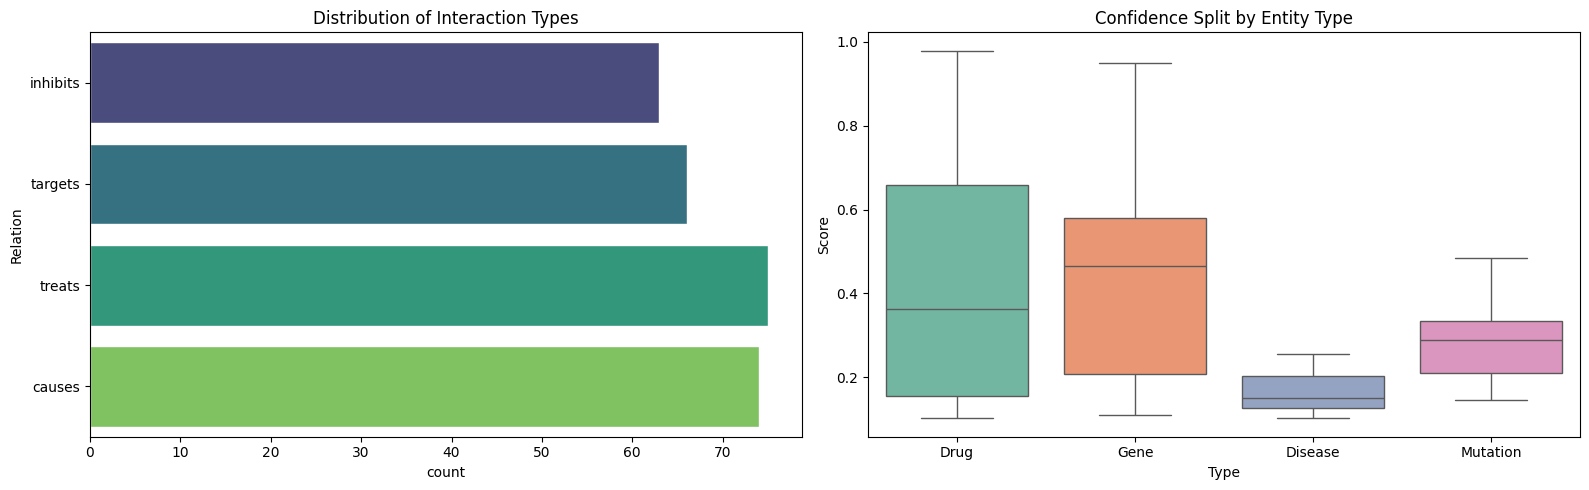

In [ ]:
# 4. Visual Dashboard: Discovery Distribution (Safe Access)
def show_discovery_plots(triplets):
    if not triplets:
        print("No data to plot.")
        return

    data = []
    for t in triplets:
        if isinstance(t, dict) and 'head' in t and 'tail' in t:
            data.append({
                'Relation': t.get('relation', 'unknown'),
                'Score': t.get('score', 0),
                'Type': t['head'].get('type', 'Unknown')
            })

    df = pd.DataFrame(data)
    if df.empty:
        print("No valid triplets found for plotting.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_style("whitegrid")

    # Relation Prevalence
    sns.countplot(data=df, y='Relation', hue='Relation', ax=axes[0], palette='viridis', legend=False)
    axes[0].set_title("Distribution of Interaction Types")

    # Confidence vs Type split
    sns.boxplot(data=df, x='Type', y='Score', hue='Type', ax=axes[1], palette='Set2')
    axes[1].set_title("Confidence Split by Entity Type")

    plt.tight_layout()
    plt.show()

show_discovery_plots(all_triplets)

## Step 6: Graph Inferences & Analytics
Now that we have a larger graph, we can perform inferences using Cypher. For example, we can find **High-Impact Genes** (nodes with the highest degree of connectivity across different articles) or **Co-occurrence patterns** between Drugs and Mutations.

In [ ]:
def run_local_inferences(conn):
    print("--- Top Ingested Interactions (Local) ---")
    results = conn.execute("""
        MATCH (h:Entity)-[r:INTERACTS]->(t:Entity)
        RETURN h.name, r.type, t.name, r.confidence
        ORDER BY r.confidence DESC
        LIMIT 10
    """)
    while results.has_next():
        row = results.get_next()
        print(f"[{row[1]}] {row[0]} -> {row[2]} (Conf: {row[3]:.2f})")

    print("\n--- Multi-hop Discovery: Potential Resistance Chains ---")
    discovery = conn.execute("""
        MATCH (d:Entity)-[r1:INTERACTS]->(g:Entity)-[r2:INTERACTS]->(target:Entity)
        WHERE d.label = 'Drug'
        RETURN d.name, g.name, target.name, target.label
        LIMIT 5
    """)
    while discovery.has_next():
        row = discovery.get_next()
        print(f"Hypothesis: {row[0]} might affect {row[2]} ({row[3]}) via {row[1]}")

run_local_inferences(enhanced_manager.conn)

--- Top Ingested Interactions (Local) ---
[causes] Osimertinib -> acquired resistance (Conf: 0.99)
[causes] Osimertinib -> acquired resistance (Conf: 0.99)
[treats] Osimertinib -> non-small cell lung cancer (Conf: 0.98)
[treats] Osimertinib -> non-small cell lung cancer (Conf: 0.98)
[treats] osimertinib -> lung adenocarcinoma (Conf: 0.98)
[treats] osimertinib -> lung adenocarcinoma (Conf: 0.98)
[inhibits] Osimertinib -> epidermal growth factor receptor (Conf: 0.97)
[inhibits] Osimertinib -> epidermal growth factor receptor (Conf: 0.97)
[targets] natural small-molecule drugs -> hnRNPA1 (Conf: 0.96)
[targets] natural small-molecule drugs -> hnRNPA1 (Conf: 0.96)

--- Multi-hop Discovery: Potential Resistance Chains ---
Hypothesis: TruSight Oncology 500 ctDNA might affect non-small cell lung cancer (Disease) via NSCLC
Hypothesis: TSO500 might affect non-small cell lung cancer (Disease) via NSCLC
Hypothesis: Guardant360 CDx might affect non-small cell lung cancer (Disease) via NSCLC
Hypothe

### 🧠 Interpreting Multi-hop Graph Reasoning

Standard RAG models often struggle with 'indirect' relationships. If Paper A mentions **Osimertinib** as a **third-generation TKI** and Paper B mentions that **third-generation TKIs** lead to **acquired resistance**, a vector search for 'Osimertinib resistance' might miss the connection if those specific words don't appear in the same snippet.

**Multi-hop Graph Reasoning** solves this by traversing the graph:
1.  **Hop 1**: `(Osimertinib)` -[:CAUSES]-> `(third-generation EGFR-TKI)`
2.  **Hop 2**: `(third-generation EGFR-TKI)` -[:CAUSES]-> `(acquired resistance)`

By executing the code below, we programmatically discover these **hidden pathways**, allowing the AI to hypothesize about indirect effects based on the structured knowledge extracted from the literature.

In [ ]:
def discover_multi_hop_pathways(conn, drug_name):
    print(f"--- Multi-hop Reasoning: Indirect Effects for {drug_name} ---")

    # This query looks for paths of length 2: Drug -> Entity A -> Entity B
    # to find what a drug might be affecting indirectly.
    query = """
        MATCH (d:Entity)-[r1:INTERACTS]->(intermediate:Entity)-[r2:INTERACTS]->(target:Entity)
        WHERE d.name CONTAINS $drug AND d.label = 'Drug'
        RETURN d.name as Drug,
               r1.type as Rel1,
               intermediate.name as Intermediate,
               r2.type as Rel2,
               target.name as Target,
               target.label as TargetType
        LIMIT 10
    """

    res = conn.execute(query, {"drug": drug_name})

    found = False
    while res.has_next():
        found = True
        row = res.get_next()
        print(f"[Path Found]: {row[0]} --({row[1]})--> {row[2]} --({row[3]})--> {row[4]} ({row[5]})")
        print(f"  Hypothesis: {row[0]} potentially influences {row[4]} through its interaction with {row[2]}.\n")

    if not found:
        print(f"No multi-hop pathways found for {drug_name} in the current graph.")

# Run the discovery on a known drug in the dataset
discover_multi_hop_pathways(enhanced_manager.conn, "Osimertinib")

--- Multi-hop Reasoning: Indirect Effects for Osimertinib ---
[Path Found]: Osimertinib --(treats)--> NSCLC --(causes)--> non-small cell lung cancer (Disease)
  Hypothesis: Osimertinib potentially influences non-small cell lung cancer through its interaction with NSCLC.

[Path Found]: Osimertinib --(treats)--> NSCLC --(causes)--> non-small cell lung cancer (Disease)
  Hypothesis: Osimertinib potentially influences non-small cell lung cancer through its interaction with NSCLC.

[Path Found]: Osimertinib --(treats)--> NSCLC --(causes)--> non-small cell lung cancer (Disease)
  Hypothesis: Osimertinib potentially influences non-small cell lung cancer through its interaction with NSCLC.

[Path Found]: Osimertinib --(treats)--> NSCLC --(causes)--> non-small cell lung cancer (Disease)
  Hypothesis: Osimertinib potentially influences non-small cell lung cancer through its interaction with NSCLC.

[Path Found]: Osimertinib --(causes)--> third-generation EGFR-TKI --(causes)--> acquired resistanc

In [ ]:
def infer_treatments_and_resistance(manager, gene_name):
    """
    Performs graph traversal to find treatments or resistance associations for a specific gene.
    """
    with manager.driver.session() as session:
        print(f"--- Intelligence Report for: {gene_name} ---")
        query = """
        MATCH (g:Gene {name: $gene})
        OPTIONAL MATCH (d:Drug)-[r1]->(g)
        OPTIONAL MATCH (g)-[r2]->(dis:Disease)
        RETURN d.name as Drug, type(r1) as DrugRel, dis.name as Condition, r2.source_context as Evidence
        LIMIT 10
        """
        results = session.run(query, gene=gene_name)
        for record in results:
            if record['Drug']:
                print(f"[Treatment/Interference] {record['Drug']} {record['DrugRel']} {gene_name}")
            if record['Condition']:
                print(f"[Pathology] Linked to {record['Condition']} | Evidence: {record['Evidence']}")

# Example usage (assuming manager is initialized):
# infer_treatments_and_resistance(manager, "EGFR")

## Hybrid RAG Implementation

To complete the Hybrid RAG, you would now use a Vector Store (like Chroma or FAISS) for the raw abstracts and the Neo4j Graph for structured reasoning.

### How to use this for Q&A:
1. **Vector Search**: Retrieve abstracts related to a user query (e.g., 'EGFR resistance').
2. **Graph Traversal**: Find relationships with high `evidence_level` or multiple `occurrences` in the Knowledge Graph.
3. **LLM Synthesis**: Pass both the retrieved text and the specific graph-extracted facts (e.g., 'Drug X treats Disease Y as seen in 15 papers') to the LLM.

### Comparing Retrieval Strategies: Vector vs. GraphRAG

In a **Simple Vector RAG**, the system retrieves the most similar text chunks based on the query. If you ask about 'EGFR resistance', you get snippets mentioning those keywords.

In **GraphRAG**, the system identifies the entities in your query, traverses their neighbors (e.g., finding which mutations cause the resistance and which drugs target those mutations), and synthesizes a path of evidence.

In [ ]:
def compare_local_rag(conn, query_entity):
    print(f"QUERY: 'What are the mechanisms for {query_entity} resistance?'\n")

    print("--- [LOCAL GRAPHRAG RETRIEVAL] ---")
    results = conn.execute("""
        MATCH (g:Entity)-[r:INTERACTS]->(m:Entity)
        WHERE g.name CONTAINS $name
        RETURN g.name, m.name, r.type, r.context
        LIMIT 3
    """, {"name": query_entity})

    if not results.has_next():
        print("No structural matches found for this entity.")

    while results.has_next():
        row = results.get_next()
        print(f"RELATIONSHIP FOUND: {row[0]} {row[2]} {row[1]}")
        print(f"  ℳ SOURCE EVIDENCE: \"{row[3]}\"\n")

compare_local_rag(enhanced_manager.conn, "EGFR")

QUERY: 'What are the mechanisms for EGFR resistance?'

--- [LOCAL GRAPHRAG RETRIEVAL] ---
RELATIONSHIP FOUND: EGFR causes resistance mechanisms
  ℳ SOURCE EVIDENCE: "Liquid biopsy has emerged as a valuable tool for detecting therapeutic targets and resistance mechanisms. This study evaluated the analytical performance and clinical utility of TruSight Oncology 500 ctDNA (TSO500) compared to the FDA-approved Guarda..."

RELATIONSHIP FOUND: EGFR causes molecular drivers
  ℳ SOURCE EVIDENCE: "Liquid biopsy has emerged as a valuable tool for detecting therapeutic targets and resistance mechanisms. This study evaluated the analytical performance and clinical utility of TruSight Oncology 500 ctDNA (TSO500) compared to the FDA-approved Guarda..."

RELATIONSHIP FOUND: EGFR causes mutations
  ℳ SOURCE EVIDENCE: "Liquid biopsy has emerged as a valuable tool for detecting therapeutic targets and resistance mechanisms. This study evaluated the analytical performance and clinical utility of TruSight

## Why GraphRAG Wins on 'Distant' Knowledge

### The Proximity Problem in Vector RAG
Classical Vector RAG breaks documents into **chunks** (e.g., 500 words). If a paper mentions a *Gene* on page 1 and a *Drug* on page 20, the vector search will likely retrieve them as isolated pieces of information. It cannot 'see' the connection unless they appear in the same snippet.

### The Semantic Bridge in GraphRAG
GraphRAG solves this through **Entity Resolution**:
1. **Global Identity**: Every time 'EGFR' is mentioned across 1,000 different papers, it points to the **same central node** in the graph.
2. **Path Traversal**: You can query for `(Drug A)-[:INHIBITS]->(Gene B)-[:ASSOCIATED_WITH]->(Disease C)`.
3. **Indirect Linking**: Even if Paper 1 only talks about Drug A and Gene B, and Paper 2 only talks about Gene B and Disease C, the Graph **automatically links Drug A to Disease C** via the shared Gene B node.

This allows for 'multi-hop' reasoning across an entire library of literature that a simple similarity search would miss.

In [ ]:
def explain_distant_linking_demo():
    print("SCENARIO: Connecting Paper A and Paper B")
    print("="*50)
    print("Paper A: 'Compound X was found to bind strongly to the K-Ras protein.'")
    print("Paper B: 'Mutations in K-Ras are the primary driver of Pancreatic Adenocarcinoma.'")
    print("-"*50)
    print("VECTOR RAG LIMITATION:")
    print("Searching for 'Pancreatic Cancer treatments' might retrieve Paper B, ")
    print("but ignore Paper A because 'Compound X' and 'Pancreatic' never appear together.")
    print("\nGRAPHRAG ADVANTAGE:")
    print("1. Node(Compound X) --[BINDS]--> Node(K-Ras)")
    print("2. Node(K-Ras) --[CAUSES]--> Node(Pancreatic Cancer)")
    print("RESULT: The graph reveals the path: Compound X -> K-Ras -> Pancreatic Cancer.")

explain_distant_linking_demo()

SCENARIO: Connecting Paper A and Paper B
Paper A: 'Compound X was found to bind strongly to the K-Ras protein.'
Paper B: 'Mutations in K-Ras are the primary driver of Pancreatic Adenocarcinoma.'
--------------------------------------------------
VECTOR RAG LIMITATION:
Searching for 'Pancreatic Cancer treatments' might retrieve Paper B, 
but ignore Paper A because 'Compound X' and 'Pancreatic' never appear together.

GRAPHRAG ADVANTAGE:
1. Node(Compound X) --[BINDS]--> Node(K-Ras)
2. Node(K-Ras) --[CAUSES]--> Node(Pancreatic Cancer)
RESULT: The graph reveals the path: Compound X -> K-Ras -> Pancreatic Cancer.
